# SPC-150 FIFO timing and metadata review

Parse a Becker & Hickl SPC/SET acquisition pair, preserve its metadata, validate macrotime reconstruction, and assign photons to camera frames from marker 2. The primary outputs are timing diagnostics and a frame table; photon plots are optional.

In [12]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

from spc150_fifo_parser import (
    assign_photons_to_frames,
    build_summary,
    build_unified_event_dataframe,
    parse_spc150_fifo,
    require_set_metadata,
    resolve_sync_rate_hz,
)

## Run configuration

The SPC and SET files are treated as one acquisition. Change both paths together.

In [13]:
SPC_PATH = Path("test_camera_30fps.spc")
SET_PATH = Path("test_camera_30fps.set")

SYNC_RATE_HZ_OVERRIDE = None  # normally read from the SPC header
FRAME_MARKER_ID = 2
EXPECTED_FRAME_RATE_HZ = 30.0
KEEP_PARTIAL_LAST_FRAME = True
FRAME_TO_INSPECT = 2
PLOT_SELECTED_FRAME = True

# Optional outputs. Leave as None to avoid writing files.
EXPORT_DIRECTORY = None
PLOT_PHOTON_QC = True

## Load the acquisition pair

In [14]:
set_metadata = require_set_metadata(SET_PATH)
set_params = set_metadata.spc_params
arrays, marker_events, header_word = parse_spc150_fifo(SPC_PATH)
sync_rate_hz, sync_rate_source = resolve_sync_rate_hz(
    SYNC_RATE_HZ_OVERRIDE, set_params, header_word=header_word
)
if sync_rate_hz is None:
    raise ValueError("Unable to determine the macrotime clock.")

summary = build_summary(
    spc_path=SPC_PATH,
    set_module=set_metadata.module,
    set_params=set_params,
    arrays=arrays,
    marker_events=marker_events,
    header_word=header_word,
    sync_rate_hz=sync_rate_hz,
    sync_rate_source=sync_rate_source,
    set_path=SET_PATH,
    set_metadata=set_metadata,
)

events_df = build_unified_event_dataframe(arrays, sync_rate_hz)
framed_events_df, frame_table_df = assign_photons_to_frames(
    events_df,
    marker_id=FRAME_MARKER_ID,
    keep_partial_last_frame=KEEP_PARTIAL_LAST_FRAME,
)

## Run identity and acquisition metadata

In [15]:
embedded_spc_name = Path(str(set_params.get("SP_SPE_FN", "")).replace("\\", "/")).name
identity = {
    "SPC file": str(SPC_PATH),
    "SET file": str(SET_PATH),
    "SET references SPC": embedded_spc_name,
    "Filename match": embedded_spc_name.casefold() == SPC_PATH.name.casefold(),
    "Module": set_metadata.module,
    "Serial number": set_metadata.serial_number,
    **{key.replace("_", " ").title(): value for key, value in set_metadata.identification.items()},
}
display(pd.Series(identity, name="value").to_frame())

important_keys = [
    "SP_MODE", "SP_FIF_TYP", "SP_MTCLK", "SP_MST_CLK",
    "SP_SYN_FQ", "SP_TAC_R", "SP_TAC_TC", "SP_ADC_RE",
    "SP_TRIGGER", "SP_ROUT", "SP_NCX", "SP_NCY",
    "SP_IMG_X", "SP_IMG_Y", "SP_CH_EN", "SP_SPE_FN",
]
important_metadata_df = pd.DataFrame(
    {"value": [set_params.get(key) for key in important_keys]},
    index=pd.Index(important_keys, name="parameter"),
)
display(important_metadata_df)

,value
SPC file,test_camera_30fps.spc
SET file,test_camera_30fps.set
SET references SPC,test_camera_30fps.spc
Filename match,True
Module,SPC-150
Serial number,3F0431
Id,SPC Setup Script File
Title,test_camera_30fps
Version,2 990 M
Revision,12 bits ADC


,value
parameter,
SP_MODE,11
SP_FIF_TYP,0
SP_MTCLK,1
SP_MST_CLK,0
SP_SYN_FQ,-300.0
SP_TAC_R,0.0
SP_TAC_TC,0.0
SP_ADC_RE,4096
SP_TRIGGER,0


To inspect every stored parameter, select a group below. SP contains acquisition settings, while PR and DI contain print and display configuration.

In [16]:
METADATA_GROUP = "SP"
metadata_group_df = pd.Series(
    set_metadata.parameter_groups[METADATA_GROUP],
    name="value",
).rename_axis("parameter").to_frame()
display(metadata_group_df)
print(
    "Parameter groups:",
    {group: len(values) for group, values in set_metadata.parameter_groups.items()},
)

,value
parameter,
SP_MODE,11
SP_CFD_LL,-50.980392
SP_CFD_LH,80.0
SP_CFD_ZC,12.850393
SP_CFD_HF,5.0
...,...
SP_CH_F2,0
SP_TDC_OF1,0.0
SP_TDC_OF2,0.0


Parameter groups: {'PR': 14, 'SP': 101, 'DI': 49}


## Record parsing diagnostics

In [17]:
event_times = arrays["macrotime_ticks"][~arrays["is_overflow"]]
backward_steps = int(np.sum(np.diff(event_times) < 0))
record_diagnostics = pd.Series(
    {
        "Total data records": arrays["records"].size,
        "Valid photons": int(np.sum(arrays["is_photon"])),
        "Invalid photon records": int(np.sum(arrays["is_invalid_photon"])),
        "Standalone overflow records": int(np.sum(arrays["is_overflow"])),
        "Reconstructed overflow wraps": int(np.sum(arrays["overflow_wraps"])),
        "Raw marker records": int(np.sum(arrays["is_marker"])),
        "Marker-2 frame pulses": summary.marker2_pulse_count,
        "Backward event timestamps": backward_steps,
        "Macrotime clock (Hz)": sync_rate_hz,
        "Macrotime clock source": sync_rate_source,
    },
    name="value",
).to_frame()
display(record_diagnostics)

,value
Total data records,343051
Valid photons,14460
Invalid photon records,180829
Standalone overflow records,138966
Reconstructed overflow wraps,297832
Raw marker records,8796
Marker-2 frame pulses,1830
Backward event timestamps,0
Macrotime clock (Hz),20000000.0
Macrotime clock source,spc-header


## Camera-frame timing

In [18]:
complete_frames = frame_table_df.dropna(subset=["frame_end_s"]).copy()
complete_frames["duration_s"] = (
    complete_frames["frame_end_s"] - complete_frames["frame_start_s"]
)
durations = complete_frames["duration_s"].to_numpy(dtype=float)
mean_duration = float(np.mean(durations)) if durations.size else np.nan
measured_frame_rate = 1.0 / mean_duration if mean_duration > 0 else np.nan
rate_error_ppm = (
    (measured_frame_rate / EXPECTED_FRAME_RATE_HZ - 1.0) * 1e6
    if EXPECTED_FRAME_RATE_HZ and np.isfinite(measured_frame_rate)
    else np.nan
)
timing_diagnostics = pd.Series(
    {
        "Frame starts": len(frame_table_df),
        "Complete frame intervals": len(complete_frames),
        "First frame start (s)": frame_table_df["frame_start_s"].iloc[0],
        "Last frame start (s)": frame_table_df["frame_start_s"].iloc[-1],
        "Mean interval (ms)": mean_duration * 1e3,
        "Interval standard deviation (us)": float(np.std(durations)) * 1e6,
        "Minimum interval (ms)": float(np.min(durations)) * 1e3,
        "Maximum interval (ms)": float(np.max(durations)) * 1e3,
        "Measured frame rate (Hz)": measured_frame_rate,
        "Expected frame rate (Hz)": EXPECTED_FRAME_RATE_HZ,
        "Frame-rate error (ppm)": rate_error_ppm,
        "Median valid photons/frame": float(complete_frames["photon_count"].median()),
    },
    name="value",
).to_frame()
display(timing_diagnostics)

,value
Frame starts,1830.000000
Complete frame intervals,1829.000000
First frame start (s),0.020444
Last frame start (s),60.994035
Mean interval (ms),33.337119
Interval standard deviation (us),0.484616
Minimum interval (ms),33.335750
Maximum interval (ms),33.338600
Measured frame rate (Hz),29.996593
Expected frame rate (Hz),30.000000


In [19]:
assert sync_rate_hz > 0, "Macrotime clock must be positive."
assert backward_steps == 0, "Reconstructed event timestamps move backward."
assert len(complete_frames) > 0, "No complete camera frames were reconstructed."
assert embedded_spc_name.casefold() == SPC_PATH.name.casefold(), (
    "The SET file references a different SPC filename."
)
print("Timing and acquisition-pair checks passed.")

Timing and acquisition-pair checks passed.


## Frame table

In [20]:
display(complete_frames.head(10))
display(complete_frames.tail(10))

,frame_marker_record_index,frame_start_ticks,frame_start_s,frame_index,next_record_index,frame_end_ticks,frame_end_s,photon_count,duration_s
0,93,408874,0.020444,0,270.0,1075596.0,0.053780,5,0.033336
1,270,1075596,0.053780,1,448.0,1742358.0,0.087118,4,0.033338
2,448,1742358,0.087118,2,611.0,2409100.0,0.120455,8,0.033337
3,611,2409100,0.120455,3,802.0,3075843.0,0.153792,8,0.033337
4,802,3075843,0.153792,4,990.0,3742584.0,0.187129,5,0.033337
5,990,3742584,0.187129,5,1155.0,4409322.0,0.220466,5,0.033337
6,1155,4409322,0.220466,6,1335.0,5076069.0,0.253803,5,0.033337
7,1335,5076069,0.253803,7,1503.0,5742797.0,0.287140,3,0.033336
8,1503,5742797,0.287140,8,1705.0,6409532.0,0.320477,16,0.033337
9,1705,6409532,0.320477,9,1881.0,7076297.0,0.353815,8,0.033338


,frame_marker_record_index,frame_start_ticks,frame_start_s,frame_index,next_record_index,frame_end_ticks,frame_end_s,photon_count,duration_s
1819,341065,1213213261,60.660663,1819,341299.0,1.213880e+09,60.694000,12,0.033337
1820,341299,1213879992,60.694000,1820,341514.0,1.214547e+09,60.727337,11,0.033338
1821,341514,1214546743,60.727337,1821,341742.0,1.215213e+09,60.760675,9,0.033337
1822,341742,1215213492,60.760675,1822,341928.0,1.215880e+09,60.794012,8,0.033338
1823,341928,1215880242,60.794012,1823,342134.0,1.216547e+09,60.827349,9,0.033337
1824,342134,1216546986,60.827349,1824,342294.0,1.217214e+09,60.860686,5,0.033337
1825,342294,1217213727,60.860686,1825,342477.0,1.217880e+09,60.894023,11,0.033337
1826,342477,1217880466,60.894023,1826,342653.0,1.218547e+09,60.927360,3,0.033336
1827,342653,1218547193,60.927360,1827,342851.0,1.219214e+09,60.960697,5,0.033338
1828,342851,1219213948,60.960697,1828,343039.0,1.219881e+09,60.994035,10,0.033337


## Photon data for a selected camera frame

Set FRAME_TO_INSPECT in the configuration cell. The table is always available; plotting is optional because blocked-detector frames may contain very few valid photons.

In [21]:
def photons_for_frame(frame_index):
    return framed_events_df.loc[
        (framed_events_df["type"] == "photon")
        & (framed_events_df["frame_index"] == int(frame_index))
    ].copy()


selected_frame_photons_df = photons_for_frame(FRAME_TO_INSPECT)
selected_frame_row = frame_table_df.loc[
    frame_table_df["frame_index"] == FRAME_TO_INSPECT
]
if selected_frame_row.empty:
    raise ValueError(f"Frame {FRAME_TO_INSPECT} is outside the available frame range.")

selected_frame_row = selected_frame_row.iloc[0]
selected_frame_summary = pd.Series(
    {
        "Frame index": FRAME_TO_INSPECT,
        "Marker record index": selected_frame_row["frame_marker_record_index"],
        "Frame start (s)": selected_frame_row["frame_start_s"],
        "Frame end (s)": selected_frame_row["frame_end_s"],
        "Frame duration (ms)": (
            selected_frame_row["frame_end_s"] - selected_frame_row["frame_start_s"]
        ) * 1e3,
        "Valid photons": len(selected_frame_photons_df),
        "Detector channels represented": selected_frame_photons_df["detector_channel_1based"].nunique(),
    },
    name="value",
).to_frame()
display(selected_frame_summary)
display(selected_frame_photons_df)

,value
Frame index,2.000000
Marker record index,448.000000
Frame start (s),0.087118
Frame end (s),0.120455
Frame duration (ms),33.337100
Valid photons,8.000000
Detector channels represented,7.000000


,record_index,word_index,type,macrotime_ticks,macrotime_s,detector_channel,detector_channel_1based,nanotime_bin,marker_mask,marker_id,...,marker2,marker3,aux,frame_index,frame_start_s,frame_end_s,frame_start_ticks,frame_end_ticks,frame_marker_record_index,next_frame_marker_record_index
29,476,477,photon,1869398,0.093470,12,13,1711,<NA>,<NA>,...,<NA>,<NA>,4,2,0.087118,0.120455,1742358,2409100,448,611
30,506,507,photon,1963609,0.098180,11,12,2107,<NA>,<NA>,...,<NA>,<NA>,4,2,0.087118,0.120455,1742358,2409100,448,611
31,530,531,photon,2069428,0.103471,6,7,2522,<NA>,<NA>,...,<NA>,<NA>,4,2,0.087118,0.120455,1742358,2409100,448,611
32,559,560,photon,2201574,0.110079,0,1,3608,<NA>,<NA>,...,<NA>,<NA>,0,2,0.087118,0.120455,1742358,2409100,448,611
33,561,562,photon,2205494,0.110275,13,14,3564,<NA>,<NA>,...,<NA>,<NA>,4,2,0.087118,0.120455,1742358,2409100,448,611
34,569,570,photon,2223541,0.111177,7,8,1529,<NA>,<NA>,...,<NA>,<NA>,0,2,0.087118,0.120455,1742358,2409100,448,611
35,588,589,photon,2287389,0.114369,10,11,1948,<NA>,<NA>,...,<NA>,<NA>,4,2,0.087118,0.120455,1742358,2409100,448,611
36,598,599,photon,2369559,0.118478,0,1,597,<NA>,<NA>,...,<NA>,<NA>,0,2,0.087118,0.120455,1742358,2409100,448,611


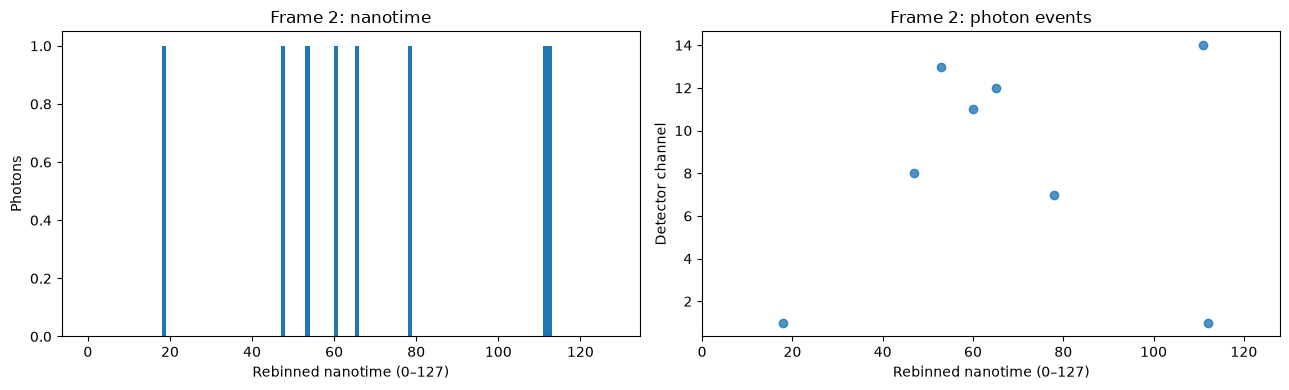

In [22]:
if PLOT_SELECTED_FRAME:
    import matplotlib.pyplot as plt

    adc_bins = int(set_params["SP_ADC_RE"])
    display_bins = 128
    frame_plot_data = selected_frame_photons_df.dropna(
        subset=["nanotime_bin", "detector_channel_1based"]
    ).copy()
    frame_plot_data["nanotime_bin_128"] = np.minimum(
        frame_plot_data["nanotime_bin"].astype(int) * display_bins // adc_bins,
        display_bins - 1,
    )

    if frame_plot_data.empty:
        print(f"Frame {FRAME_TO_INSPECT} contains no valid photons.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].hist(
            frame_plot_data["nanotime_bin_128"],
            bins=np.arange(display_bins + 1),
        )
        axes[0].set(
            title=f"Frame {FRAME_TO_INSPECT}: nanotime",
            xlabel="Rebinned nanotime (0–127)",
            ylabel="Photons",
        )

        axes[1].scatter(
            frame_plot_data["nanotime_bin_128"],
            frame_plot_data["detector_channel_1based"],
            alpha=0.8,
        )
        axes[1].set(
            title=f"Frame {FRAME_TO_INSPECT}: photon events",
            xlabel="Rebinned nanotime (0–127)",
            ylabel="Detector channel",
            xlim=(0, display_bins),
        )
        fig.tight_layout()
        plt.show()
else:
    print("Selected-frame plot disabled; set PLOT_SELECTED_FRAME = True to enable it.")

## Optional aggregate photon QC

This uses all valid photons, not a single dilute frame. Raw ADC bins are explicitly rebinned from the SET-file resolution to 128 display bins.

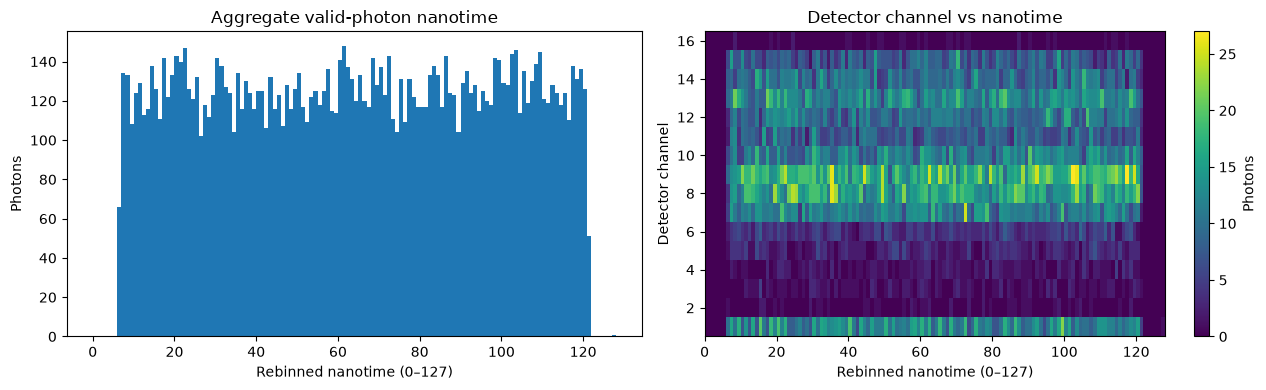

In [23]:
if PLOT_PHOTON_QC:
    import matplotlib.pyplot as plt

    adc_bins = int(set_params["SP_ADC_RE"])
    display_bins = 128
    photons = framed_events_df.loc[
        framed_events_df["type"] == "photon",
        ["nanotime_bin", "detector_channel_1based"],
    ].dropna().copy()
    photons["nanotime_bin_128"] = np.minimum(
        photons["nanotime_bin"].astype(int) * display_bins // adc_bins,
        display_bins - 1,
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(photons["nanotime_bin_128"], bins=np.arange(display_bins + 1))
    axes[0].set(title="Aggregate valid-photon nanotime", xlabel="Rebinned nanotime (0–127)", ylabel="Photons")

    channels = photons["detector_channel_1based"].astype(int)
    channel_edges = np.arange(channels.min() - 0.5, channels.max() + 1.5)
    heatmap, xedges, yedges = np.histogram2d(
        photons["nanotime_bin_128"], channels,
        bins=[np.arange(display_bins + 1), channel_edges],
    )
    mesh = axes[1].pcolormesh(xedges, yedges, heatmap.T, shading="auto")
    axes[1].set(title="Detector channel vs nanotime", xlabel="Rebinned nanotime (0–127)", ylabel="Detector channel")
    fig.colorbar(mesh, ax=axes[1], label="Photons")
    fig.tight_layout()
    plt.show()
else:
    print("Photon QC plot disabled; set PLOT_PHOTON_QC = True to enable it.")

## Optional exports

In [ ]:
if EXPORT_DIRECTORY is not None:
    export_directory = Path(EXPORT_DIRECTORY)
    export_directory.mkdir(parents=True, exist_ok=True)
    events_path = export_directory / f"{SPC_PATH.stem}_events.csv"
    frames_path = export_directory / f"{SPC_PATH.stem}_frames.csv"
    summary_path = export_directory / f"{SPC_PATH.stem}_summary.json"
    framed_events_df.to_csv(events_path, index=False)
    frame_table_df.to_csv(frames_path, index=False)
    summary_path.write_text(json.dumps(summary.__dict__, indent=2, sort_keys=True), encoding="utf-8")
    print("Wrote:", events_path, frames_path, summary_path, sep="\n- ")
else:
    print("Exports disabled; set EXPORT_DIRECTORY to enable them.")